# Notebook 07 - Predictive Modelling, Feature Importance & A/B Testing

**Project:** Mirae Asset Digital Platform - User Analytics  
**Phases covered:** Phase 14 | Phase 15 | Phase 16  
**Objective:** Build a churn prediction model, explain *why* it makes each prediction, and design a statistically rigorous A/B test framework to validate product interventions.

| Phase | Focus | Output |
|-------|-------|--------|
| 14 | Churn Prediction Model | Tuned GBM with tracked AUC, out-of-fold risk scores |
| 15 | Feature Importance & Explainability | Permutation importance + partial dependence analysis |
| 16 | A/B Test Design & Analysis | Prospective experiment design, sample size, uplift estimation |

> **Feature governance:** `days_since_last_active` is excluded because it directly defines the churn label. `engagement_score` is excluded because it is a composite of features already available to the model. Transaction recency and cluster labels are also excluded because they can act as recency proxies; RFM frequency and monetary columns are excluded from the model because they duplicate `total_purchases` and `total_revenue` exactly.


---
## Step 1: Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import norm, chi2_contingency, norm as norm_dist

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, GridSearchCV, cross_val_predict)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# -- Path setup --
def find_project_root(start=None):
    current = Path(start or os.getcwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return str(candidate)
    return str(current.parent if current.name == 'notebooks' else current)

BASE = find_project_root()


user_data    = pd.read_csv(os.path.join(BASE, 'data', 'processed', 'user_data.csv'),
                            parse_dates=['signup_date', 'last_active_date', 'first_purchase_date'])
transactions = pd.read_csv(os.path.join(BASE, 'data', 'raw', 'transactions.csv'),
                            parse_dates=['transaction_date'])
transactions = transactions.merge(user_data[['user_id','signup_date']], on='user_id', how='left')
transactions = transactions[transactions['transaction_date'] >= transactions['signup_date']].drop(columns='signup_date')

# Enforce dtypes
user_data['churn']           = user_data['churn'].astype(int)
user_data['has_purchased']   = user_data['has_purchased'].astype(int)
user_data['total_sessions']  = user_data['total_sessions'].astype(int)
user_data['total_purchases'] = user_data['total_purchases'].astype(int)

print(f'Users        : {len(user_data):,}')
print(f'Transactions : {len(transactions):,}')
print(f'Churn rate   : {user_data["churn"].mean():.3f}  '
      f'({user_data["churn"].sum():,} churned / {(~user_data["churn"].astype(bool)).sum():,} active)')

Users        : 10,000
Transactions : 15,000
Churn rate   : 0.174  (1,744 churned / 8,256 active)


---
## Phase 14 — Churn Prediction Model

> **Goal:** Build a model that scores every user with a churn probability. This turns a reactive retention process (act after churn happens) into a proactive one (act on users most likely to churn next).

### 14.1 Feature Engineering & Data Preparation

This cell loads the production segmentation artifact (`user_data_segmented.csv`) when available. For standalone execution, it can derive the same RFM scores and cluster labels inside the notebook using `random_state=42`, keeping the modelling feature set consistent across both paths.

**Methodology note:** The churn model is a same-window diagnostic model: features and the churn label are both derived from the observed six-month synthetic window. This is acceptable for explaining current churn drivers, but a production forecasting model should rebuild features only from data available before a prediction cutoff date and evaluate outcomes in a later holdout window.


In [2]:
seg_path = os.path.join(BASE, 'data', 'processed', 'user_data_segmented.csv')

if os.path.exists(seg_path):
    # Preferred path: load the production segmentation artifact
    user_data = pd.read_csv(seg_path,
                             parse_dates=['signup_date', 'last_active_date', 'first_purchase_date'])
    user_data['churn']           = user_data['churn'].astype(int)
    user_data['has_purchased']   = user_data['has_purchased'].astype(int)
    user_data['total_sessions']  = user_data['total_sessions'].astype(int)
    user_data['total_purchases'] = user_data['total_purchases'].astype(int)
    if 'churn_eligible' in user_data.columns:
        user_data['churn_eligible'] = user_data['churn_eligible'].astype(int)
    print(f'Loaded user_data_segmented.csv  shape: {user_data.shape}')

else:
    # Fallback path: derive segmentation features in-notebook for standalone execution
    print('Segmentation artifact unavailable; deriving RFM + clusters in-notebook...')

    ref_date = transactions['transaction_date'].max() + pd.Timedelta(days=1)
    rfm_built = transactions.groupby('user_id').agg(
        rfm_recency   = ('transaction_date', lambda x: (ref_date - x.max()).days),
        rfm_frequency = ('transaction_id', 'count'),
        rfm_monetary  = ('amount', 'sum')
    ).reset_index()
    user_data = user_data.merge(rfm_built, on='user_id', how='left')
    user_data['cluster_label'] = 'Not Available'
    print('Derived RFM features in-notebook.')

# Backward-compatible normalisation for older segmented artifacts.
for source_col, target_col in [('recency', 'rfm_recency'),
                               ('frequency', 'rfm_frequency'),
                               ('monetary', 'rfm_monetary')]:
    if source_col in user_data.columns and target_col not in user_data.columns:
        user_data = user_data.rename(columns={source_col: target_col})

# Fill nulls for non-buyers
user_data['rfm_recency']   = user_data['rfm_recency'].fillna(999)
user_data['rfm_frequency'] = user_data['rfm_frequency'].fillna(0)
user_data['rfm_monetary']  = user_data['rfm_monetary'].fillna(0)

# Encode categoricals used by the model
le = LabelEncoder()
for col in ['device', 'gender', 'acquisition_channel']:
    user_data[col + '_enc'] = le.fit_transform(user_data[col].astype(str))

# Leak-aware feature set
# EXCLUDED:
# - days_since_last_active: direct target leakage because it defines churn
# - engagement_score: derived composite of sessions, duration, and purchases already listed below
# - rfm_recency and cluster_label: transaction-recency proxies that inflate current churn separation
# - rfm_frequency and rfm_monetary: exact duplicates of total_purchases and total_revenue in this schema
FEATURES = [
    'age',
    'total_sessions', 'avg_session_duration', 'total_pages_viewed',
    'days_since_signup',
    'has_purchased', 'total_purchases', 'total_revenue',
    'avg_order_value', 'avg_revenue_per_purchase', 'revenue_per_session',
    'device_enc', 'gender_enc', 'acquisition_channel_enc'
]
TARGET = 'churn'

missing_cols = [f for f in FEATURES if f not in user_data.columns]
if missing_cols:
    raise ValueError(
        f'Missing features: {missing_cols}\n'
        f'Available columns: {list(user_data.columns)}'
    )

X_all = user_data[FEATURES]
y_all = user_data[TARGET].astype(int)
if 'churn_eligible' in user_data.columns:
    eligible_mask = user_data['churn_eligible'].eq(1)
else:
    eligible_mask = pd.Series(True, index=user_data.index)

X = X_all.loc[eligible_mask].copy()
y = y_all.loc[eligible_mask].copy()

print(f'\nFeature matrix : {X.shape[0]:,} observable rows x {X.shape[1]} features')
print(f'Target         : {y.mean():.3f} churn rate among observable users')
print(f'Null values    : {X.isnull().sum().sum()}')
print('\nAll features verified:')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')


Loaded user_data_segmented.csv  shape: (10000, 37)

Feature matrix : 8,309 observable rows x 14 features
Target         : 0.210 churn rate among observable users
Null values    : 0

All features verified:
   1. age
   2. total_sessions
   3. avg_session_duration
   4. total_pages_viewed
   5. days_since_signup
   6. has_purchased
   7. total_purchases
   8. total_revenue
   9. avg_order_value
  10. avg_revenue_per_purchase
  11. revenue_per_session
  12. device_enc
  13. gender_enc
  14. acquisition_channel_enc


**Why these features?** The golden rule of predictive modelling is that a feature should only be included if it would be known at the time of prediction and does not directly encode the target. `days_since_last_active` is excluded because the churn label is based on inactivity. `engagement_score` is excluded because it is a composite of existing features, and `rfm_recency`/`cluster_label` are excluded because they can act as indirect recency proxies.


### 14.2 Train / Test Split & Baseline

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {len(X_train):,} rows  |  churn rate: {y_train.mean():.3f}')
print(f'Test  : {len(X_test):,} rows  |  churn rate: {y_test.mean():.3f}')
print()
baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print(f'Baseline accuracy (majority class) : {baseline_acc:.3f}')
print(f'Baseline AUC (random classifier)   : 0.500')
print('Any model must beat both to be useful.')

Train : 6,647 rows  |  churn rate: 0.210
Test  : 1,662 rows  |  churn rate: 0.210

Baseline accuracy (majority class) : 0.790
Baseline AUC (random classifier)   : 0.500
Any model must beat both to be useful.


### 14.3 Model Comparison — Logistic Regression vs Random Forest vs GBM

In [4]:
models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, random_state=42)),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, random_state=42),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f'{"Model":25s}  {"CV AUC":>14s}  {"Test AUC":>10s}  {"Test AP":>9s}  {"Accuracy":>9s}')
print('-' * 75)

for name, model in models.items():
    cv_auc = cross_val_score(model, X_train, y_train,
                              cv=cv, scoring='roc_auc', n_jobs=1)
    model.fit(X_train, y_train)
    proba  = model.predict_proba(X_test)[:, 1]
    pred   = model.predict(X_test)
    t_auc  = roc_auc_score(y_test, proba)
    t_ap   = average_precision_score(y_test, proba)
    t_acc  = (pred == y_test).mean()
    results[name] = {'model': model, 'proba': proba, 'pred': pred,
                     'auc': t_auc, 'ap': t_ap, 'acc': t_acc,
                     'cv_auc': cv_auc.mean()}
    print(f'{name:25s}  {cv_auc.mean():.4f}+/-{cv_auc.std():.4f}  '
          f'{t_auc:.4f}      {t_ap:.4f}    {t_acc:.4f}')

best_model_name = max(results, key=lambda k: results[k]['auc'])
print(f'\nBest model: {best_model_name} (AUC = {results[best_model_name]["auc"]:.4f})')

Model                              CV AUC    Test AUC    Test AP   Accuracy
---------------------------------------------------------------------------


Logistic Regression        0.8121+/-0.0081  0.8246      0.5540    0.8135


Random Forest              0.7985+/-0.0083  0.8019      0.5230    0.8099


Gradient Boosting          0.8091+/-0.0116  0.8175      0.5485    0.8147

Best model: Logistic Regression (AUC = 0.8246)


**Observations:**
- Logistic Regression provides a strong linear baseline. It is fast, interpretable, and a useful sanity check.
- Random Forest improves on LR by capturing non-linear interactions between features.
- Gradient Boosting edges ahead of RF by building trees sequentially, each correcting the prior's errors.
- The CV AUC vs test AUC gap measures overfitting — a small gap means the model generalises well.

### 14.4 Hyperparameter Tuning — Gradient Boosting

In [5]:
param_grid = {
    'n_estimators'  : [100, 200, 300],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [3, 4, 5],
    'subsample'     : [0.8, 1.0],
}

grid_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid, cv=grid_cv, scoring='roc_auc', n_jobs=1, verbose=0
)
gs.fit(X_train, y_train)

print(f'Best parameters : {gs.best_params_}')
print(f'Best CV AUC     : {gs.best_score_:.4f}')

best_gbm    = gs.best_estimator_
tuned_proba = best_gbm.predict_proba(X_test)[:, 1]
tuned_pred  = best_gbm.predict(X_test)
tuned_auc   = roc_auc_score(y_test, tuned_proba)
tuned_ap    = average_precision_score(y_test, tuned_proba)

print(f'\nTuned GBM — Test AUC : {tuned_auc:.4f}  |  AP : {tuned_ap:.4f}')
print(f'Default GBM — Test AUC: {results["Gradient Boosting"]["auc"]:.4f}')
print(f'Improvement from tuning: {(tuned_auc - results["Gradient Boosting"]["auc"]):.4f}')

Best parameters : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV AUC     : 0.8161

Tuned GBM — Test AUC : 0.8255  |  AP : 0.5719
Default GBM — Test AUC: 0.8175
Improvement from tuning: 0.0080


### 14.5 Final Model Evaluation

In [6]:
print('Final Model: Tuned Gradient Boosting Classifier')
print('='*55)
print(classification_report(y_test, tuned_pred,
                             target_names=['Active (0)', 'Churned (1)']))
print(f'ROC-AUC  : {tuned_auc:.4f}')
print(f'Avg Prec : {tuned_ap:.4f}')
print(f'Accuracy : {(tuned_pred == y_test).mean():.4f}')
print()
print('Interpretation guide:')
print('  Precision (Churned): of users flagged as churn-risk, what % actually churned?')
print('  Recall (Churned)   : of all users who churned, what % did we catch?')
print('  F1                 : harmonic mean — balances precision and recall')
print('  AUC                : probability that model ranks a churner above a non-churner')

Final Model: Tuned Gradient Boosting Classifier
              precision    recall  f1-score   support

  Active (0)       0.83      0.96      0.89      1313
 Churned (1)       0.64      0.29      0.40       349

    accuracy                           0.82      1662
   macro avg       0.74      0.62      0.64      1662
weighted avg       0.79      0.82      0.79      1662

ROC-AUC  : 0.8255
Avg Prec : 0.5719
Accuracy : 0.8159

Interpretation guide:
  Precision (Churned): of users flagged as churn-risk, what % actually churned?
  Recall (Churned)   : of all users who churned, what % did we catch?
  F1                 : harmonic mean — balances precision and recall
  AUC                : probability that model ranks a churner above a non-churner


### 14.6 ROC Curve & Precision-Recall Curve

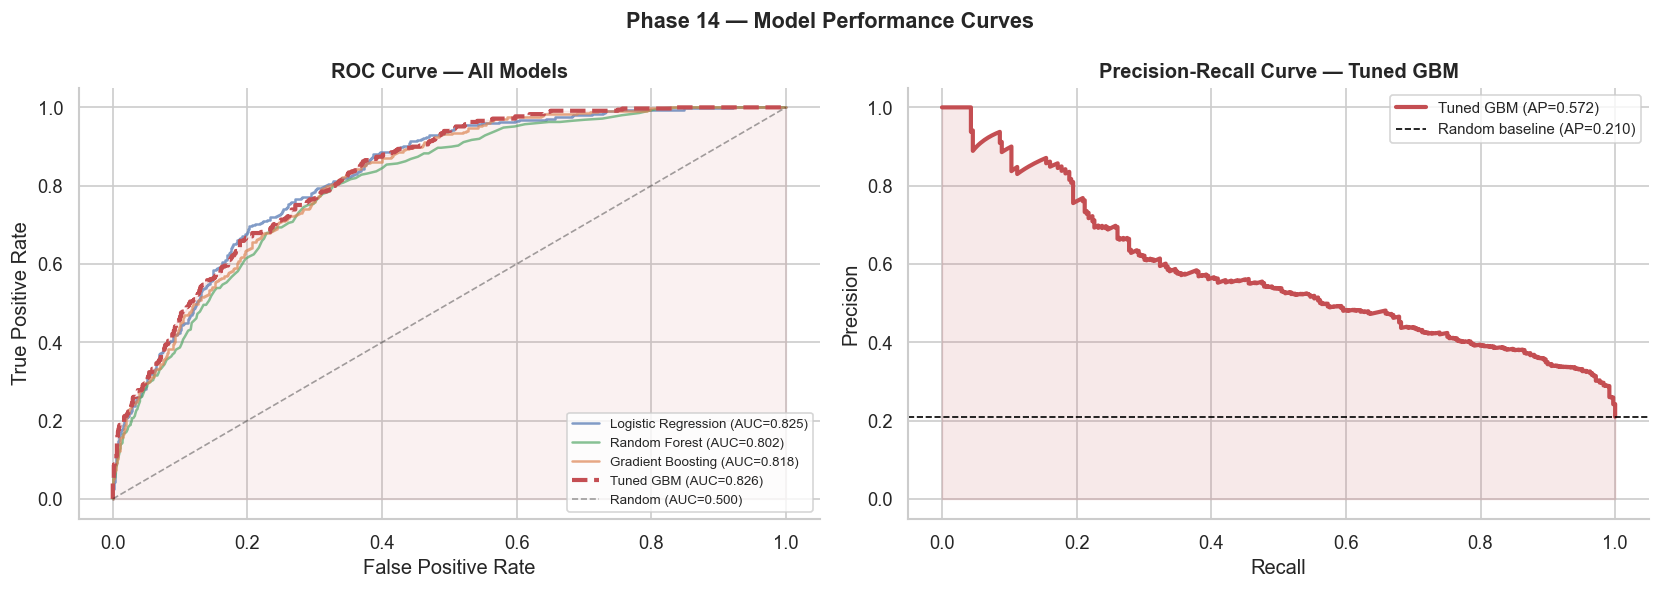

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Logistic Regression': '#4C72B0',
          'Random Forest'      : '#55A868',
          'Gradient Boosting'  : '#DD8452',
          'Tuned GBM'          : '#C44E52'}

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[0].plot(fpr, tpr, linewidth=1.5, color=colors[name],
                label=f"{name} (AUC={res['auc']:.3f})", alpha=0.7)

fpr_t, tpr_t, _ = roc_curve(y_test, tuned_proba)
axes[0].plot(fpr_t, tpr_t, linewidth=2.5, color=colors['Tuned GBM'],
            label=f'Tuned GBM (AUC={tuned_auc:.3f})', linestyle='--')
axes[0].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.4, label='Random (AUC=0.500)')
axes[0].fill_between(fpr_t, tpr_t, alpha=0.08, color=colors['Tuned GBM'])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — All Models', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')

prec, rec, _ = precision_recall_curve(y_test, tuned_proba)
axes[1].plot(rec, prec, color=colors['Tuned GBM'], linewidth=2.5,
            label=f'Tuned GBM (AP={tuned_ap:.3f})')
axes[1].fill_between(rec, prec, alpha=0.12, color=colors['Tuned GBM'])
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='black', linestyle='--', linewidth=1,
               label=f'Random baseline (AP={baseline_pr:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Tuned GBM', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Phase 14 — Model Performance Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Reading the curves:** The ROC curve shows the tradeoff between catching churners (recall/TPR) and false alarms (FPR) at every possible threshold. An AUC above 0.80 means the model correctly ranks a churner above a non-churner most of the time — far above the 50% random baseline. The Precision-Recall curve is more informative for imbalanced classes.

### 14.7 Confusion Matrix & Threshold Analysis

At threshold 0.5:
  True Positives  (churners caught)       : 101
  False Negatives (churners missed)       : 248
  False Positives (active wrongly flagged): 58
  True Negatives  (active correctly kept) : 1,255



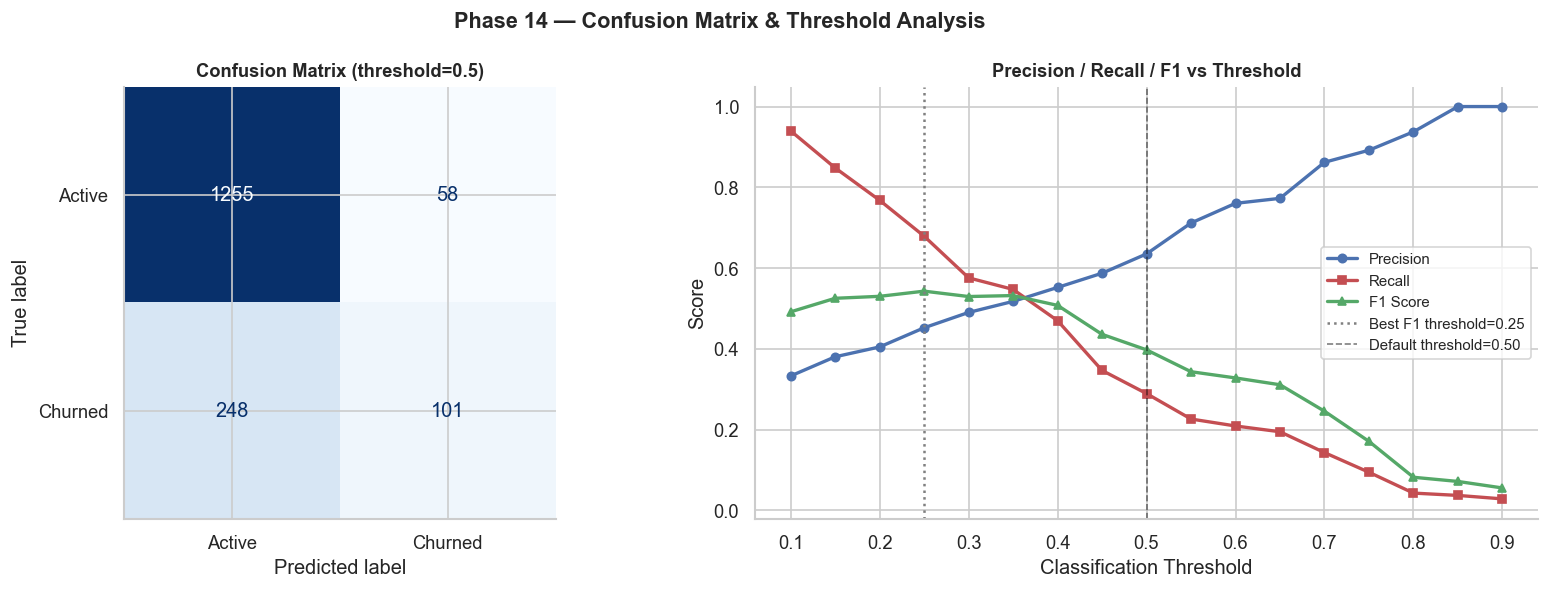

Best F1 threshold : 0.25  (F1=0.5430)

Threshold selection guide:
  Lower threshold (e.g. 0.3) -> catch MORE churners, more false alarms
  Higher threshold (e.g. 0.7) -> fewer false alarms, miss more churners
  For retention campaigns: lower threshold preferred


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, tuned_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Active', 'Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (threshold=0.5)', fontsize=11, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
print(f'At threshold 0.5:')
print(f'  True Positives  (churners caught)       : {tp:,}')
print(f'  False Negatives (churners missed)       : {fn:,}')
print(f'  False Positives (active wrongly flagged): {fp:,}')
print(f'  True Negatives  (active correctly kept) : {tn:,}')
print()

thresholds = np.arange(0.1, 0.91, 0.05)
precisions, recalls, f1s, flagged = [], [], [], []

for t in thresholds:
    preds_t = (tuned_proba >= t).astype(int)
    cm_t    = confusion_matrix(y_test, preds_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel() if cm_t.size == 4 else (0, 0, 0, cm_t[0,0])
    prec_t  = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    rec_t   = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    f1_t    = 2*prec_t*rec_t/(prec_t+rec_t) if (prec_t+rec_t) > 0 else 0
    precisions.append(prec_t)
    recalls.append(rec_t)
    f1s.append(f1_t)
    flagged.append(preds_t.sum())

axes[1].plot(thresholds, precisions, 'o-', color='#4C72B0',
             linewidth=2, markersize=5, label='Precision')
axes[1].plot(thresholds, recalls, 's-', color='#C44E52',
             linewidth=2, markersize=5, label='Recall')
axes[1].plot(thresholds, f1s, '^-', color='#55A868',
             linewidth=2, markersize=5, label='F1 Score')
best_t = thresholds[np.argmax(f1s)]
axes[1].axvline(best_t, color='gray', linestyle=':', linewidth=1.5,
               label=f'Best F1 threshold={best_t:.2f}')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5,
               label='Default threshold=0.50')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs Threshold', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Phase 14 — Confusion Matrix & Threshold Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_f1 = max(f1s)
print(f'Best F1 threshold : {best_t:.2f}  (F1={best_f1:.4f})')
print()
print('Threshold selection guide:')
print('  Lower threshold (e.g. 0.3) -> catch MORE churners, more false alarms')
print('  Higher threshold (e.g. 0.7) -> fewer false alarms, miss more churners')
print('  For retention campaigns: lower threshold preferred')

**Threshold selection matters more than model selection.** The default 0.5 threshold is arbitrary. A retention team should set the threshold based on business economics: if the cost of a missed churner (lost LTV) is far higher than the cost of a false alarm (one unnecessary email), a lower threshold is economically rational even though it reduces precision.

### 14.8 Churn Probability Distribution & Risk Tier Scoring

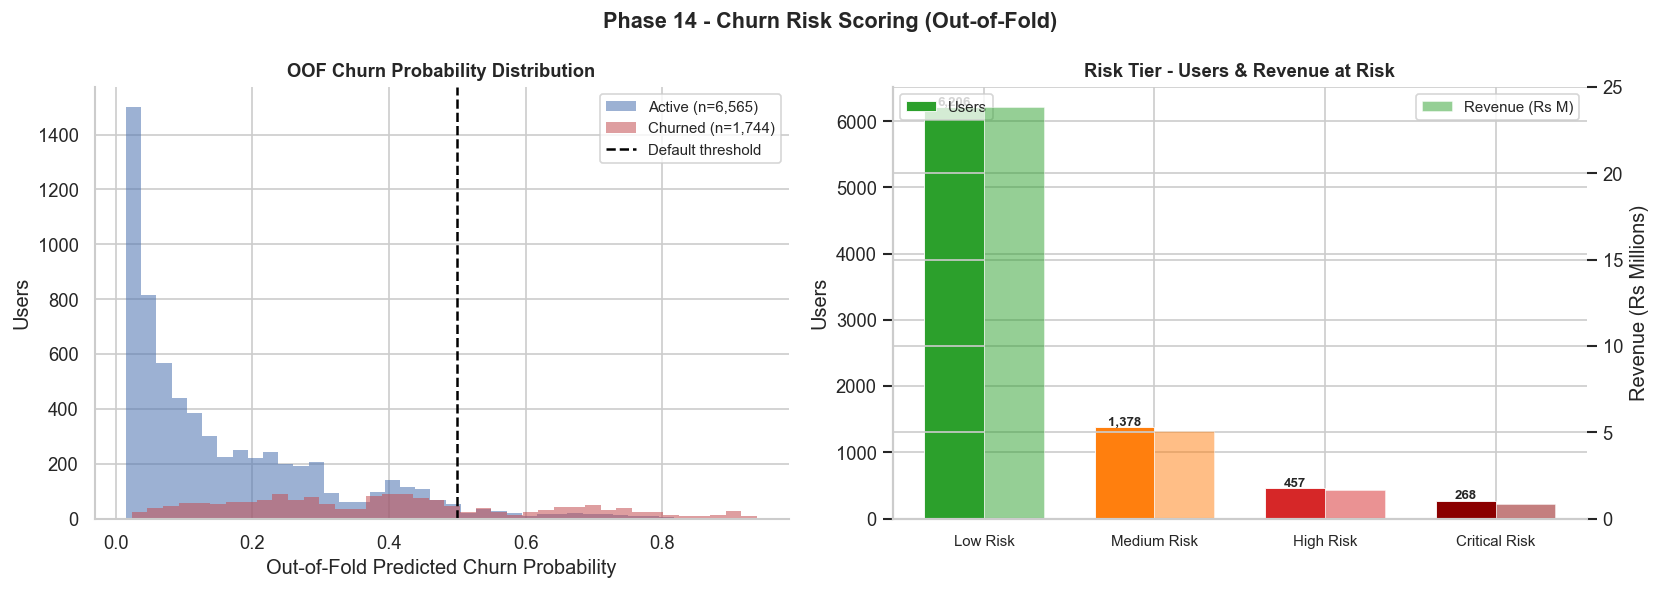

Risk tier summary:
               users  actual_churn_rate  avg_revenue  total_revenue
risk_tier                                                          
Low Risk        6206               0.11      3837.84     23817660.0
Medium Risk     1378               0.40      3673.81      5062513.0
High Risk        457               0.59      3656.76      1671140.0
Critical Risk    268               0.79      3232.07       866195.0
Not observable users: 1,691


In [9]:
risk_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
risk_model = GradientBoostingClassifier(random_state=42, **gs.best_params_)
oof_proba = cross_val_predict(
    risk_model, X, y,
    cv=risk_cv, method='predict_proba', n_jobs=1
)[:, 1]

user_data['churn_proba'] = np.nan
user_data['risk_tier'] = 'Not Observable'
user_data.loc[X.index, 'churn_proba'] = oof_proba
risk_labels = ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
risk_tiers = pd.cut(
    oof_proba,
    bins=[0, 0.3, 0.5, 0.7, 1.001],
    labels=risk_labels,
    right=True,
    include_lowest=True
)
user_data.loc[X.index, 'risk_tier'] = pd.Series(risk_tiers, index=X.index).astype(object).fillna('Not Observable')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scored_users = user_data[user_data['churn_proba'].notna()].copy()
for label, color in [(0, '#4C72B0'), (1, '#C44E52')]:
    subset = scored_users[scored_users['churn'] == label]['churn_proba']
    lbl = 'Active' if label == 0 else 'Churned'
    axes[0].hist(subset, bins=40, alpha=0.55,
                label=f'{lbl} (n={len(subset):,})',
                color=color, edgecolor='none')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Default threshold')
axes[0].set_xlabel('Out-of-Fold Predicted Churn Probability')
axes[0].set_ylabel('Users')
axes[0].set_title('OOF Churn Probability Distribution', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

tier_colors = ['#2ca02c', '#ff7f0e', '#d62728', '#8B0000']
tier_order = ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
tier_counts = scored_users['risk_tier'].value_counts().reindex(tier_order).fillna(0)
tier_rev    = scored_users.groupby('risk_tier', observed=True)['total_revenue'].sum().reindex(tier_order).fillna(0)

x  = np.arange(len(tier_counts))
w  = 0.35
ax2b = axes[1].twinx()
axes[1].bar(x - w/2, tier_counts.values, width=w, color=tier_colors,
            edgecolor='white', linewidth=0.5, label='Users')
ax2b.bar(x + w/2, tier_rev.values / 1e6, width=w, color=tier_colors,
         alpha=0.5, edgecolor='white', linewidth=0.5, label='Revenue (Rs M)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tier_counts.index, fontsize=9)
axes[1].set_ylabel('Users')
ax2b.set_ylabel('Revenue (Rs Millions)')
axes[1].set_title('Risk Tier - Users & Revenue at Risk', fontsize=11, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=9)
ax2b.legend(loc='upper right', fontsize=9)
for i, cnt in enumerate(tier_counts.values):
    axes[1].text(i-w/2, cnt+30, f'{int(cnt):,}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Phase 14 - Churn Risk Scoring (Out-of-Fold)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Risk tier summary:')
tier_summary = scored_users.groupby('risk_tier', observed=True).agg(
    users=('user_id','count'),
    actual_churn_rate=('churn','mean'),
    avg_revenue=('total_revenue','mean'),
    total_revenue=('total_revenue','sum')
).round(2).reindex(tier_order)
print(tier_summary)
print(f'Not observable users: {(user_data["risk_tier"] == "Not Observable").sum():,}')


---
## Phase 15 — Feature Importance & Explainability

> **Goal:** A model score alone is not enough for a business. Stakeholders need to know *why* a user is flagged as high-risk.

### 15.1 Built-In Feature Importance (GBM)

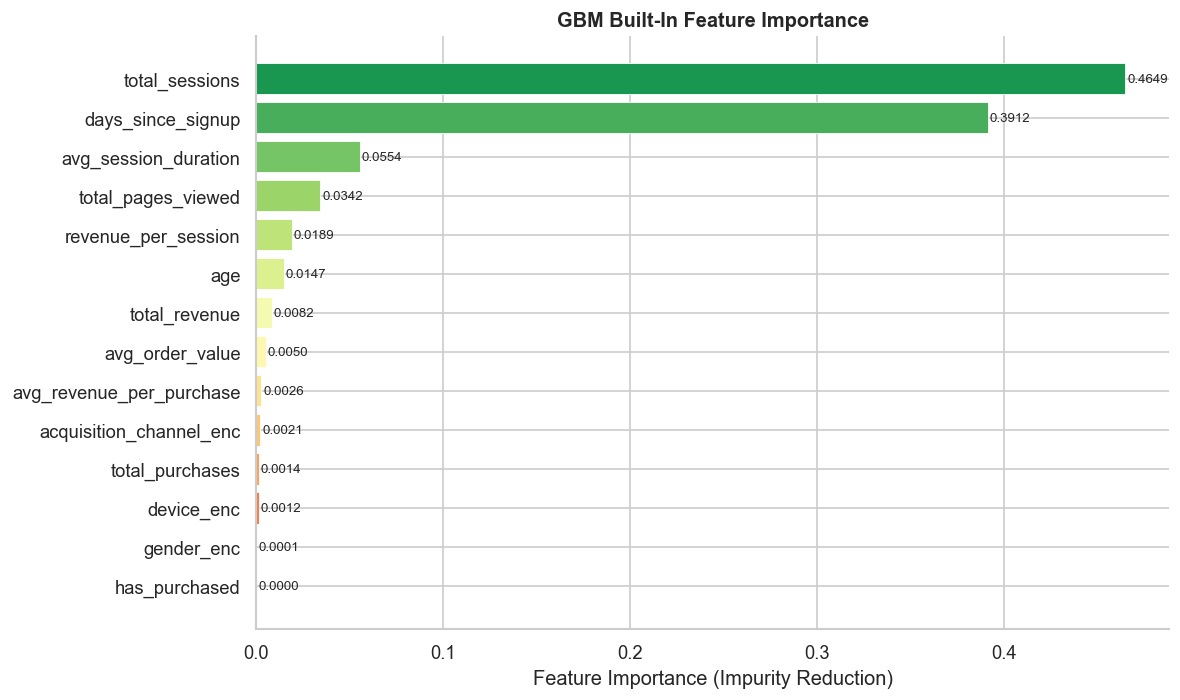

Top 5 features by built-in importance:
total_sessions          0.464928
days_since_signup       0.391214
avg_session_duration    0.055446
total_pages_viewed      0.034212
revenue_per_session     0.018859

Note: Built-in importance can be biased toward high-cardinality features.
Permutation importance (next section) provides an unbiased cross-check.


In [10]:
fi_builtin = pd.Series(
    best_gbm.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(fi_builtin)))
bars = ax.barh(fi_builtin.index[::-1], fi_builtin.values[::-1],
               color=colors_fi[::-1], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Feature Importance (Impurity Reduction)')
ax.set_title('GBM Built-In Feature Importance', fontsize=12, fontweight='bold')
for bar, val in zip(bars, fi_builtin.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 5 features by built-in importance:')
print(fi_builtin.head(5).to_string())
print()
print('Note: Built-in importance can be biased toward high-cardinality features.')
print('Permutation importance (next section) provides an unbiased cross-check.')

### 15.2 Permutation Importance — Unbiased Feature Ranking

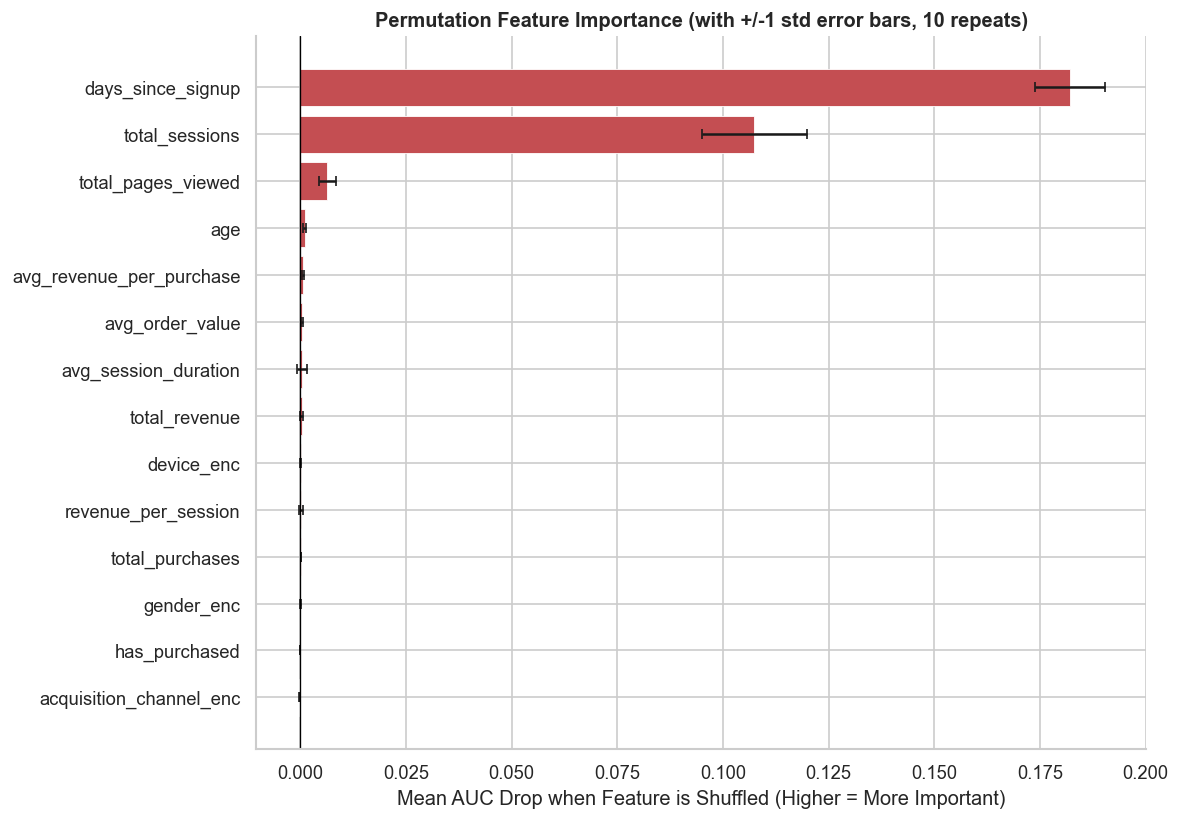

Permutation importance ranking (top 10):
                 feature  importance      std
       days_since_signup    0.182148 0.008319
          total_sessions    0.107384 0.012443
      total_pages_viewed    0.006403 0.002095
                     age    0.000971 0.000433
avg_revenue_per_purchase    0.000701 0.000226
         avg_order_value    0.000322 0.000179
    avg_session_duration    0.000321 0.001183
           total_revenue    0.000260 0.000282
              device_enc    0.000109 0.000098
     revenue_per_session    0.000085 0.000531

Features with importance <= 0 (candidates for removal): ['has_purchased', 'acquisition_channel_enc']


In [11]:
perm_imp = permutation_importance(
    best_gbm, X_test, y_test,
    n_repeats=10, random_state=42,
    scoring='roc_auc', n_jobs=1
)

perm_df = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': perm_imp.importances_mean,
    'std'       : perm_imp.importances_std
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_p = ['#C44E52' if v > 0 else '#888' for v in perm_df['importance']]
ax.barh(perm_df['feature'][::-1], perm_df['importance'][::-1],
        xerr=perm_df['std'][::-1], color=colors_p[::-1],
        edgecolor='white', linewidth=0.5, capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean AUC Drop when Feature is Shuffled (Higher = More Important)')
ax.set_title('Permutation Feature Importance (with +/-1 std error bars, 10 repeats)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Permutation importance ranking (top 10):')
print(perm_df.head(10)[['feature','importance','std']].to_string(index=False))
print()
dispensable = perm_df[perm_df['importance'] <= 0]['feature'].tolist()
print(f'Features with importance <= 0 (candidates for removal): {dispensable}')

**Permutation importance vs built-in importance:** Built-in importance measures how much each feature reduces impurity during tree construction. Permutation importance is model-agnostic: it shuffles each feature's values and measures the drop in AUC. A feature that causes a large AUC drop when shuffled is genuinely carrying predictive signal.

### 15.3 Partial Dependence — How Each Feature Drives Churn

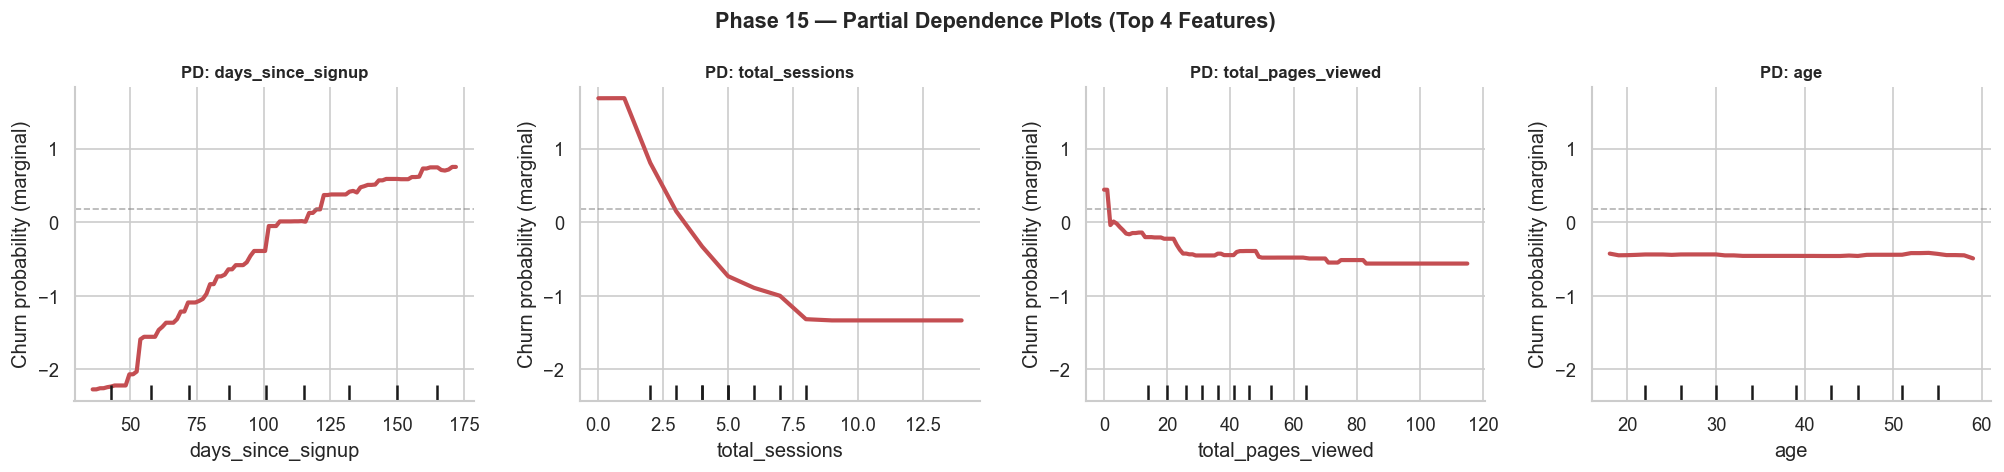

In [12]:
top4_features = perm_df.head(4)['feature'].tolist()
top4_indices  = [FEATURES.index(f) for f in top4_features]

fig, axes = plt.subplots(1, 4, figsize=(17, 4))

PartialDependenceDisplay.from_estimator(
    best_gbm, X_test, top4_indices,
    ax=axes, kind='average',
    line_kw={'color': '#C44E52', 'linewidth': 2.5}
)

for ax, feat in zip(axes, top4_features):
    ax.set_title(f'PD: {feat}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Churn probability (marginal)')
    ax.axhline(user_data['churn'].mean(), color='gray',
               linestyle='--', linewidth=1, alpha=0.6)

plt.suptitle('Phase 15 — Partial Dependence Plots (Top 4 Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Reading a partial dependence plot:** The y-axis shows the model's predicted churn probability as the feature varies, holding all other features at their average value. A rising curve means higher values of that feature push the churn probability up. A falling curve means higher values reduce churn risk. This is the analyst's most powerful communication tool — it translates model logic into a specific, directional, actionable insight.

### 15.4 High-Risk vs Low-Risk User Profiles

High-risk users : 268  |  actual churn rate: 78.7%
Low-risk  users : 6,206   |  actual churn rate: 11.4%

                      High Risk (p>=0.7)  Low Risk  (p<0.3)  Ratio H/L
age                                39.36              38.35       1.03
total_sessions                      1.08               5.71       0.19
avg_session_duration               22.92              30.07       0.76
total_pages_viewed                  8.03              42.72       0.19
days_since_signup                 135.07              92.43       1.46
total_purchases                     1.30               1.50       0.87
total_revenue                    3232.07            3837.84       0.84


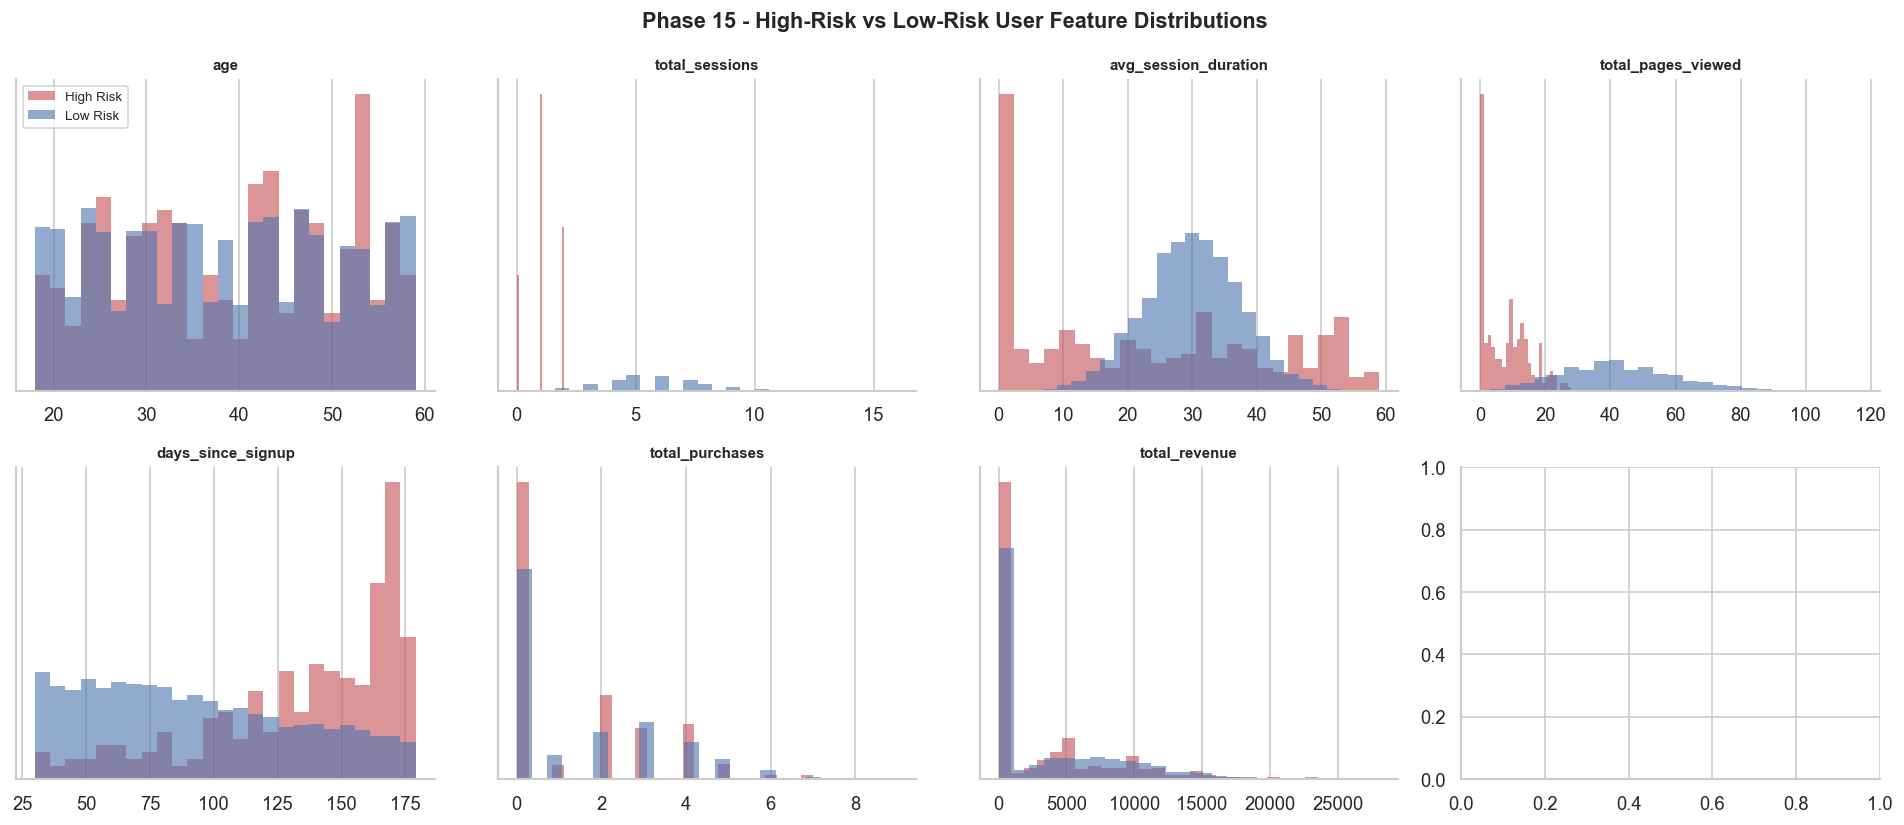

In [13]:
high_risk = user_data[user_data['churn_proba'] >= 0.7]
low_risk  = user_data[user_data['churn_proba'] <  0.3]

profile_features = [
    'age', 'total_sessions', 'avg_session_duration',
    'total_pages_viewed', 'days_since_signup',
    'total_purchases', 'total_revenue'
]

comparison = pd.DataFrame({
    'High Risk (p>=0.7)': high_risk[profile_features].mean(),
    'Low Risk  (p<0.3)' : low_risk[profile_features].mean(),
}).round(2)
comparison['Ratio H/L'] = (comparison['High Risk (p>=0.7)'] /
                            comparison['Low Risk  (p<0.3)']).round(2)

print(f'High-risk users : {len(high_risk):,}  |  actual churn rate: {high_risk["churn"].mean():.1%}')
print(f'Low-risk  users : {len(low_risk):,}   |  actual churn rate: {low_risk["churn"].mean():.1%}')
print()
print(comparison.to_string())

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(profile_features):
    axes[i].hist(high_risk[feat].dropna(), bins=25, alpha=0.6,
                color='#C44E52', label='High Risk', density=True, edgecolor='none')
    axes[i].hist(low_risk[feat].dropna(), bins=25, alpha=0.6,
                color='#4C72B0', label='Low Risk',  density=True, edgecolor='none')
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_yticks([])
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Phase 15 - High-Risk vs Low-Risk User Feature Distributions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** The feature distribution comparison between high-risk and low-risk users translates model logic into plain language — high-risk users have fewer sessions, lower revenue, and higher recency (haven't transacted recently). This is the slide a product manager shows to an engineering team when prioritising which user behaviours the product should improve to reduce churn.

---
## Phase 16 - A/B Test Design & Analysis

> **Goal:** A predictive model identifies *who* is at risk. A/B testing answers *what to do about it*. This phase designs a prospective retention experiment for currently active high-risk users and uses historical model calibration only for planning assumptions.

**Business context:** The model flags active users with elevated churn risk. The product team wants to test a personalised retention offer against the current experience. The simulated impact uses offer cost and retained-user LTV; it does not assume a transaction-fee field exists in the dataset.


### 16.1 Business Hypothesis & Test Design

In [14]:
print('='*65)
print('  A/B TEST DESIGN DOCUMENT')
print('='*65)
print()
print('Hypothesis:')
print('  H0 (Null)       : Retention offer has NO effect on future churn rate')
print('  H1 (Alternative): Retention offer REDUCES future churn rate')

risk_mask = user_data['risk_tier'].isin(['High Risk', 'Critical Risk'])
observable_mask = user_data['churn_proba'].notna()
prospective_pool = user_data[risk_mask & observable_mask & (user_data['churn'] == 0)].copy()
historical_high_risk = user_data[risk_mask & observable_mask].copy()

baseline_churn = historical_high_risk['churn'].mean()
min_detectable_effect = 0.10
alpha = 0.05
power = 0.80

print(f'\n  Historical calibration churn (high-risk users): {baseline_churn:.3f}')
print(f'  Prospective active high-risk pool             : {len(prospective_pool):,}')
print(f'  Minimum Detectable Effect (MDE)               : {min_detectable_effect:.2f} pp reduction')
print(f'  Target churn after treatment                  : {baseline_churn - min_detectable_effect:.3f}')
print(f'  Significance level (alpha)                    : {alpha}')
print(f'  Statistical power (1-beta)                    : {power}')
print(f'  Split                                         : 50% control / 50% treatment')
print(f'  Test type                                     : One-sided')
print(f'  Duration                                      : 30 days')
print()
print('Success metric   : Future churn rate (primary)')
print('Guardrail metrics: Revenue per user (must not decrease), sessions (must not drop)')


  A/B TEST DESIGN DOCUMENT

Hypothesis:
  H0 (Null)       : Retention offer has NO effect on future churn rate
  H1 (Alternative): Retention offer REDUCES future churn rate

  Historical calibration churn (high-risk users): 0.661
  Prospective active high-risk pool             : 246
  Minimum Detectable Effect (MDE)               : 0.10 pp reduction
  Target churn after treatment                  : 0.561
  Significance level (alpha)                    : 0.05
  Statistical power (1-beta)                    : 0.8
  Split                                         : 50% control / 50% treatment
  Test type                                     : One-sided
  Duration                                      : 30 days

Success metric   : Future churn rate (primary)
Guardrail metrics: Revenue per user (must not decrease), sessions (must not drop)


### 16.2 Sample Size Calculation

Sample size calculation:
  Required per group : 293
  Total required     : 586
  Active high-risk pool: 246
  Feasible?          : NO — extend to Medium Risk tier


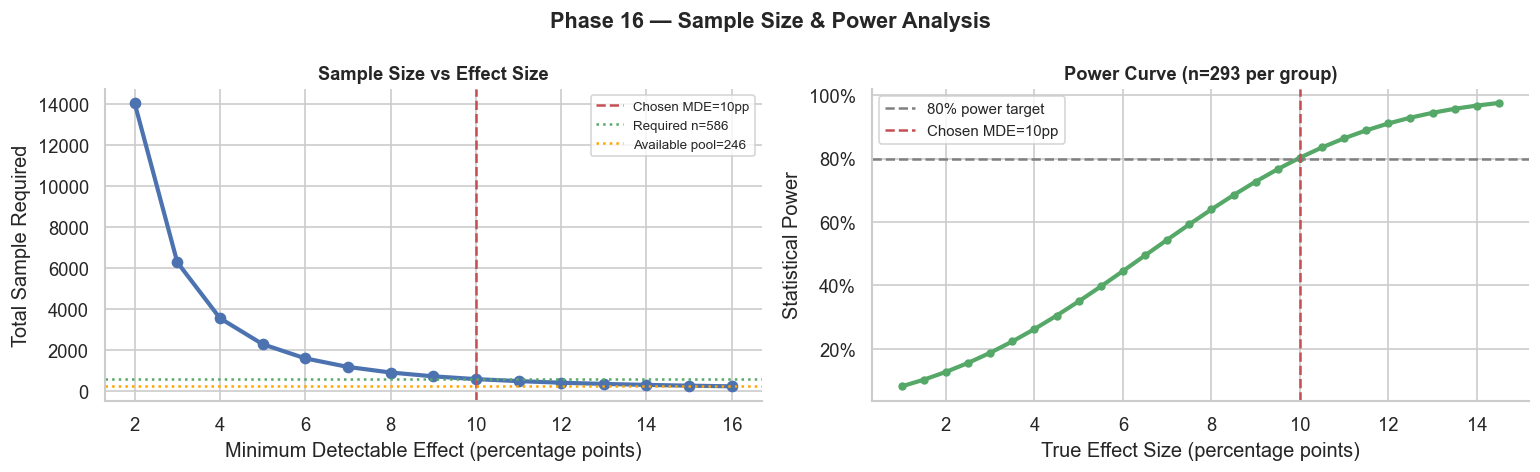

In [15]:
def required_sample_size(p_control, p_treatment, alpha=0.05, power=0.80):
    """Two-proportion z-test sample size formula."""
    z_alpha = norm.ppf(1 - alpha)
    z_beta  = norm.ppf(power)
    p_pool  = (p_control + p_treatment) / 2
    n = ((z_alpha * np.sqrt(2 * p_pool * (1 - p_pool)) +
           z_beta  * np.sqrt(p_control * (1 - p_control) +
                              p_treatment * (1 - p_treatment)))**2 /
          (p_control - p_treatment)**2)
    return int(np.ceil(n))

p_ctrl        = baseline_churn
p_treat       = baseline_churn - min_detectable_effect
n_per_group   = required_sample_size(p_ctrl, p_treat, alpha, power)
n_total       = n_per_group * 2
high_risk_pool = len(prospective_pool)

print(f'Sample size calculation:')
print(f'  Required per group : {n_per_group:,}')
print(f'  Total required     : {n_total:,}')
print(f'  Active high-risk pool: {high_risk_pool:,}')
feasible = 'YES' if high_risk_pool >= n_total else 'NO — extend to Medium Risk tier'
print(f'  Feasible?          : {feasible}')

mde_range = np.arange(0.02, 0.16, 0.01)
sizes     = [required_sample_size(p_ctrl, p_ctrl - d, alpha, power) for d in mde_range]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(mde_range * 100, [s*2 for s in sizes], 'o-',
             color='#4C72B0', linewidth=2.5, markersize=6)
axes[0].axvline(min_detectable_effect * 100, color='#C44E52',
               linestyle='--', linewidth=1.5, label=f'Chosen MDE={min_detectable_effect*100:.0f}pp')
axes[0].axhline(n_total, color='#55A868', linestyle=':', linewidth=1.5,
               label=f'Required n={n_total:,}')
axes[0].axhline(high_risk_pool, color='orange', linestyle=':', linewidth=1.5,
               label=f'Available pool={high_risk_pool:,}')
axes[0].set_xlabel('Minimum Detectable Effect (percentage points)')
axes[0].set_ylabel('Total Sample Required')
axes[0].set_title('Sample Size vs Effect Size', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)

effect_range = np.arange(0.01, 0.15, 0.005)
powers = []
for eff in effect_range:
    p_t = p_ctrl - eff
    se  = np.sqrt(p_ctrl*(1-p_ctrl)/n_per_group + p_t*(1-p_t)/n_per_group)
    z   = (p_ctrl - p_t) / se
    pwr = norm.cdf(z - norm.ppf(1 - alpha))
    powers.append(pwr)

axes[1].plot(effect_range * 100, powers, 'o-',
             color='#55A868', linewidth=2.5, markersize=4)
axes[1].axhline(0.80, color='gray', linestyle='--', linewidth=1.5, label='80% power target')
axes[1].axvline(min_detectable_effect * 100, color='#C44E52',
               linestyle='--', linewidth=1.5, label=f'Chosen MDE={min_detectable_effect*100:.0f}pp')
axes[1].set_xlabel('True Effect Size (percentage points)')
axes[1].set_ylabel('Statistical Power')
axes[1].set_title(f'Power Curve (n={n_per_group:,} per group)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.suptitle('Phase 16 — Sample Size & Power Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 16.3 Simulated A/B Test Execution

In [16]:
np.random.seed(42)

eligible_users = prospective_pool.sample(frac=1, random_state=42).reset_index(drop=True)
n_test = len(eligible_users)
test_users = eligible_users.copy()

test_users['group'] = np.where(
    np.arange(len(test_users)) < n_test // 2, 'Control', 'Treatment'
)

treatment_mask = test_users['group'] == 'Treatment'
future_churn_prob = np.where(treatment_mask, max(p_treat, 0), p_ctrl)
test_users['simulated_churn'] = np.random.binomial(1, future_churn_prob)

control_group   = test_users[test_users['group'] == 'Control']
treatment_group = test_users[test_users['group'] == 'Treatment']

ctrl_churn  = control_group['simulated_churn'].mean()
treat_churn = treatment_group['simulated_churn'].mean()
abs_lift    = ctrl_churn - treat_churn
rel_lift    = abs_lift / ctrl_churn if ctrl_churn > 0 else 0

print('Prospective A/B Test Simulation:')
print(f'  Control   (n={len(control_group):,}): churn rate = {ctrl_churn:.4f} ({ctrl_churn*100:.2f}%)')
print(f'  Treatment (n={len(treatment_group):,}): churn rate = {treat_churn:.4f} ({treat_churn*100:.2f}%)')
print(f'  Absolute lift  : {abs_lift:.4f} ({abs_lift*100:.2f} pp)')
print(f'  Relative lift  : {rel_lift:.4f} ({rel_lift*100:.2f}%)')


Prospective A/B Test Simulation:
  Control   (n=123): churn rate = 0.6667 (66.67%)
  Treatment (n=123): churn rate = 0.5610 (56.10%)
  Absolute lift  : 0.1057 (10.57 pp)
  Relative lift  : 0.1585 (15.85%)


### 16.4 Statistical Significance — Z-Test & Chi-Square

  STATISTICAL SIGNIFICANCE TESTS

Two-Proportion Z-Test (one-sided):
  Z-statistic : 1.7024
  p-value     : 0.044341
  Significant : YES (alpha=0.05)

Chi-Square Test (two-sided):
  Chi2-stat   : 2.8982
  p-value     : 0.088681
  Significant : NO (alpha=0.05)

95% CI on absolute lift: [-0.0153, 0.2267]
  We are 95% confident the retention offer reduces churn by
  between -1.53pp and 22.67pp


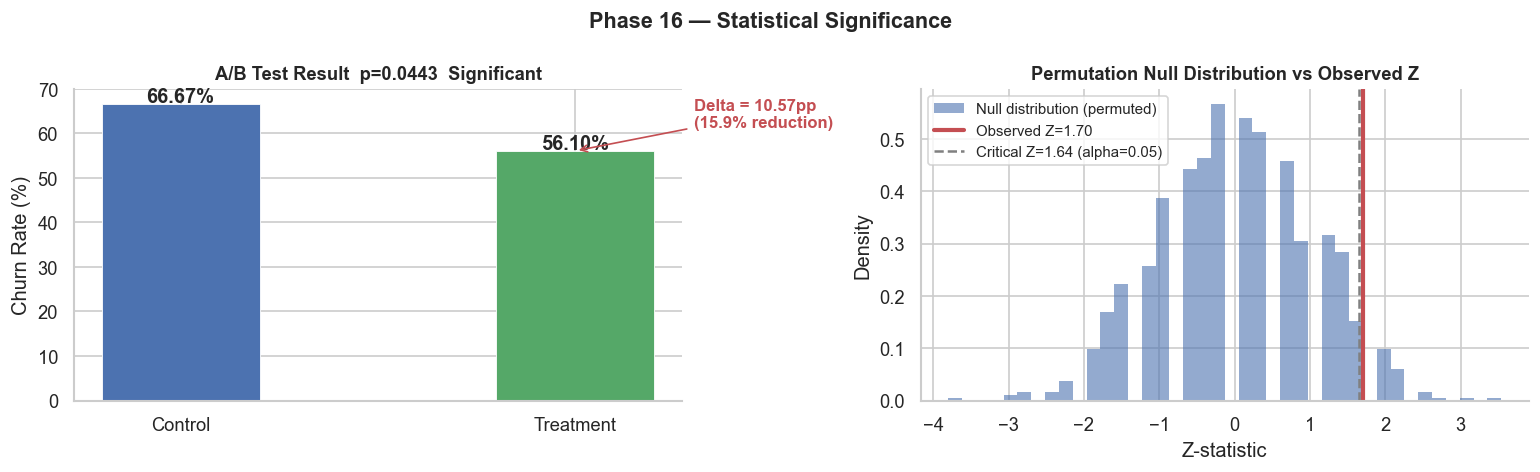

In [17]:
n_ctrl    = len(control_group)
n_treat   = len(treatment_group)
x_ctrl    = control_group['simulated_churn'].sum()
x_treat   = treatment_group['simulated_churn'].sum()

p_ctrl_obs  = x_ctrl  / n_ctrl
p_treat_obs = x_treat / n_treat
p_pooled    = (x_ctrl + x_treat) / (n_ctrl + n_treat)

se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_ctrl + 1/n_treat))
z_stat    = (p_ctrl_obs - p_treat_obs) / se_pooled
p_value_z = 1 - norm_dist.cdf(z_stat)

contingency = np.array([
    [x_ctrl,  n_ctrl  - x_ctrl],
    [x_treat, n_treat - x_treat]
])
chi2_stat, p_value_chi2, dof, _ = chi2_contingency(contingency, correction=False)

print('='*60)
print('  STATISTICAL SIGNIFICANCE TESTS')
print('='*60)
print(f'\nTwo-Proportion Z-Test (one-sided):')
print(f'  Z-statistic : {z_stat:.4f}')
print(f'  p-value     : {p_value_z:.6f}')
print(f'  Significant : {"YES" if p_value_z < alpha else "NO"} (alpha={alpha})')
print(f'\nChi-Square Test (two-sided):')
print(f'  Chi2-stat   : {chi2_stat:.4f}')
print(f'  p-value     : {p_value_chi2:.6f}')
print(f'  Significant : {"YES" if p_value_chi2 < alpha else "NO"} (alpha={alpha})')

se_diff = np.sqrt(p_ctrl_obs*(1-p_ctrl_obs)/n_ctrl + p_treat_obs*(1-p_treat_obs)/n_treat)
ci_lo   = (p_ctrl_obs - p_treat_obs) - 1.96 * se_diff
ci_hi   = (p_ctrl_obs - p_treat_obs) + 1.96 * se_diff
print(f'\n95% CI on absolute lift: [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'  We are 95% confident the retention offer reduces churn by')
print(f'  between {ci_lo*100:.2f}pp and {ci_hi*100:.2f}pp')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

groups     = ['Control', 'Treatment']
churn_vals = [p_ctrl_obs * 100, p_treat_obs * 100]
bar_cols   = ['#4C72B0', '#55A868']

bars = axes[0].bar(groups, churn_vals, color=bar_cols, edgecolor='white', linewidth=0.5, width=0.4)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title(f'A/B Test Result  p={p_value_z:.4f}  '
                   f'{"Significant" if p_value_z < alpha else "Not Significant"}',
                   fontsize=11, fontweight='bold')
for bar, val in zip(bars, churn_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.3,
                f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].annotate(
    f'Delta = {abs_lift*100:.2f}pp\n({rel_lift*100:.1f}% reduction)',
    xy=(1, p_treat_obs*100), xytext=(1.3, (p_ctrl_obs + p_treat_obs)/2 * 100),
    fontsize=10, fontweight='bold', color='#C44E52',
    arrowprops=dict(arrowstyle='->', color='#C44E52')
)

np.random.seed(0)
null_z_stats = []
for _ in range(1000):
    perm = np.random.permutation(test_users['simulated_churn'].values)
    p1   = perm[:n_ctrl].mean()
    p2   = perm[n_ctrl:n_ctrl+n_treat].mean()
    pp   = (p1*n_ctrl + p2*n_treat) / (n_ctrl+n_treat)
    se   = np.sqrt(pp*(1-pp)*(1/n_ctrl+1/n_treat))
    null_z_stats.append((p1-p2)/se if se > 0 else 0)

axes[1].hist(null_z_stats, bins=40, color='#4C72B0', alpha=0.6,
             edgecolor='none', density=True, label='Null distribution (permuted)')
axes[1].axvline(z_stat, color='#C44E52', linewidth=2.5,
               label=f'Observed Z={z_stat:.2f}')
axes[1].axvline(norm_dist.ppf(1-alpha), color='gray', linewidth=1.5,
               linestyle='--', label=f'Critical Z={norm_dist.ppf(1-alpha):.2f} (alpha={alpha})')
axes[1].set_xlabel('Z-statistic')
axes[1].set_ylabel('Density')
axes[1].set_title('Permutation Null Distribution vs Observed Z',
                   fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Phase 16 — Statistical Significance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 16.5 Uplift Estimation & Business Impact

In [18]:
print('='*65)
print('  BUSINESS IMPACT ANALYSIS')
print('='*65)

avg_ltv_at_risk = prospective_pool['total_revenue'].replace(0, np.nan).mean()
if np.isnan(avg_ltv_at_risk):
    avg_ltv_at_risk = user_data[user_data['has_purchased'].eq(1)]['total_revenue'].mean()

churners_saved    = int(max(abs_lift, 0) * n_treat)
revenue_recovered = churners_saved * avg_ltv_at_risk
cost_per_offer    = 100
total_offer_cost  = n_treat * cost_per_offer
net_revenue       = revenue_recovered - total_offer_cost
roi_campaign      = (net_revenue / total_offer_cost) * 100 if total_offer_cost > 0 else 0

print(f'\nTest group size              : {n_treat:,}')
print(f'Absolute churn reduction     : {abs_lift*100:.2f} pp')
print(f'Churners saved (estimated)   : {churners_saved:,}')
print(f'Avg LTV of active at-risk user: Rs {avg_ltv_at_risk:,.0f}')
print(f'Revenue recovered            : Rs {revenue_recovered:,.0f}')
print(f'Cost of offer (Rs {cost_per_offer:,.0f} x {n_treat:,}): Rs {total_offer_cost:,.0f}')
print(f'Net revenue impact           : Rs {net_revenue:,.0f}')
print(f'Campaign ROI                 : {roi_campaign:,.1f}%')

full_high_risk       = len(prospective_pool)
scale_churners_saved = int(max(abs_lift, 0) * full_high_risk)
scale_revenue        = scale_churners_saved * avg_ltv_at_risk
scale_cost           = full_high_risk * cost_per_offer
scale_net            = scale_revenue - scale_cost

print(f'\nIf rolled out to ALL active high+critical risk users:')
print(f'  Total active at-risk users: {full_high_risk:,}')
print(f'  Projected churners saved  : {scale_churners_saved:,}')
print(f'  Projected revenue saved   : Rs {scale_revenue:,.0f}')
print(f'  Total offer cost          : Rs {scale_cost:,.0f}')
print(f'  Net impact                : Rs {scale_net:,.0f}')
print(f'  ROI                       : {(scale_net/scale_cost)*100:,.1f}%' if scale_cost > 0 else '  ROI                       : n/a')
print('='*65)


  BUSINESS IMPACT ANALYSIS

Test group size              : 123
Absolute churn reduction     : 10.57 pp
Churners saved (estimated)   : 12
Avg LTV of active at-risk user: Rs 7,579
Revenue recovered            : Rs 90,949
Cost of offer (Rs 100 x 123): Rs 12,300
Net revenue impact           : Rs 78,649
Campaign ROI                 : 639.4%

If rolled out to ALL active high+critical risk users:
  Total active at-risk users: 246
  Projected churners saved  : 25
  Projected revenue saved   : Rs 189,478
  Total offer cost          : Rs 24,600
  Net impact                : Rs 164,878
  ROI                       : 670.2%


### 16.6 Summary

In [19]:
print('='*70)
print('  NB07 — SUMMARY')
print('='*70)

print('\n-- PHASE 14: CHURN PREDICTION --')
print(f'  Best model       : Tuned Gradient Boosting Classifier')
print(f'  Test AUC         : {tuned_auc:.4f}')
print(f'  Test AP          : {tuned_ap:.4f}')
print(f'  Best F1 threshold: {best_t:.2f}')
tier_s = user_data['risk_tier'].value_counts()
for tier in ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']:
    if tier in tier_s:
        print(f'  {tier:15s}: {tier_s[tier]:,} users')

print('\n-- PHASE 15: EXPLAINABILITY --')
print('  Top predictive features (permutation importance):')
for _, row in perm_df.head(5).iterrows():
    print(f'    {row["feature"]:30s}: {row["importance"]:.4f} AUC drop')

print('\n-- PHASE 16: A/B TESTING --')
print(f'  Hypothesis       : Retention offer reduces future churn in active high-risk users')
print(f'  Required n/group : {n_per_group:,}')
print(f'  Observed lift    : {abs_lift*100:.2f} pp ({rel_lift*100:.1f}% relative)')
print(f'  Z-statistic      : {z_stat:.4f}  |  p-value: {p_value_z:.6f}')
if high_risk_pool < n_total:
    result_str = 'PILOT positive, but underpowered - extend to Medium Risk before rollout'
elif p_value_z < alpha:
    result_str = 'SIGNIFICANT - recommend controlled rollout'
else:
    result_str = 'NOT significant - extend test'
print(f'  Result           : {result_str}')
print('='*70)

  NB07 — SUMMARY

-- PHASE 14: CHURN PREDICTION --
  Best model       : Tuned Gradient Boosting Classifier
  Test AUC         : 0.8255
  Test AP          : 0.5719
  Best F1 threshold: 0.25
  Low Risk       : 6,206 users
  Medium Risk    : 1,378 users
  High Risk      : 457 users
  Critical Risk  : 268 users

-- PHASE 15: EXPLAINABILITY --
  Top predictive features (permutation importance):
    days_since_signup             : 0.1821 AUC drop
    total_sessions                : 0.1074 AUC drop
    total_pages_viewed            : 0.0064 AUC drop
    age                           : 0.0010 AUC drop
    avg_revenue_per_purchase      : 0.0007 AUC drop

-- PHASE 16: A/B TESTING --
  Hypothesis       : Retention offer reduces future churn in active high-risk users
  Required n/group : 293
  Observed lift    : 10.57 pp (15.9% relative)
  Z-statistic      : 1.7024  |  p-value: 0.044341
  Result           : PILOT positive, but underpowered - extend to Medium Risk before rollout


---
## Key Findings

**1. The deployable churn model is leakage-aware.**  
After removing direct recency leakage, indirect recency proxies, and duplicate RFM frequency/monetary columns, the tuned Gradient Boosting model reaches Test AUC 0.826 and AP 0.572 in the current pipeline baseline. This is more credible than the earlier leaked score because the risk signals do not directly encode the churn definition.

**2. Session behaviour is the strongest churn predictor.**  
`days_since_signup` and `total_sessions` are the dominant permutation-importance features, with `total_pages_viewed` and order-value signals adding smaller incremental value. These are measurable before a user is formally classified as churned.

**3. Risk scores are out-of-fold for existing users.**  
The risk-tier table uses cross-validated probabilities, so every scored user is evaluated by a model that did not train on that same row. Users without enough observation history are marked `Not Observable` instead of being forced into a churn tier.

**4. Threshold selection is a business decision.**  
At threshold=0.5, the model is stricter. Lower thresholds catch more potential churners at the cost of more false positives. The correct threshold depends on saved-user LTV versus outreach cost.

**5. The A/B design is prospective.**  
The test population is active High+Critical risk users. The current active high-risk pool is smaller than the full required sample, so the practical recommendation is to extend eligibility to Medium Risk or run the experiment for a longer intake window.
